# Primera Práctica: Predicción de Subscripción a un Producto Bancario.

### Somos Lidia Valera López y Ana Díaz Jiménez del grupo 81
### Correos: 100522236@alumnos.uc3m.es y 100522155@alumnos.uc3m.es, respectivamente. 
### NIAS: 100522236 y 100522155, respectivamente
### Nuestra semilla es la de la alumna Lidia Valera López, por lo que nuestro bank es el 9 (3+6)

## 1. EDA Simplicado

### Cargar los datos

Lo primero que hacemos es cargar nuestros datos y además mostraremos las primeras filas del DataFrame

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Cargamos los datos
df = pd.read_pickle("bank_09.pkl") 

# Mostramos las primeras filas del DataFrame
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Número de instancias y variables

In [55]:
n_instancias, n_variables = df.shape

print(f"Número de instancias: {n_instancias}")
print(f"Número de variables: {n_variables}")

Número de instancias: 11000
Número de variables: 17


### Tipo de variables

A continuación obersavermos si las variables son numéricas, categóricas u ordinales

In [58]:
# Definimos la columna que es ordinal (nos fijamos en las filas del DataFrame para identificarla)
ordinal_vars = ["education"]

# Detectamos variables numéricas
num_vars = df.select_dtypes(include=[np.number]).columns.tolist()

# Detectamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Quitamos las columnas ordinales de las categóricas
cat_vars = [var for var in cat_vars if var not in ordinal_vars]

# Detectamos variables booleanas (contienen yes/no, Yes/No o True/False)
bool_vars = [col for col in df.columns if df[col].dropna().isin(['yes','no','Yes','No',True,False]).all()]

# Excluimos booleanas de categóricas
cat_vars = [var for var in cat_vars if var not in bool_vars]

# Mostramos resultados
print(f"Variables numéricas: {num_vars}")
print(f"Variables categóricas: {cat_vars}")
print(f"Variables ordinales: {ordinal_vars}")
print(f"Variables booleanas: {bool_vars}")

Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'contact', 'month', 'poutcome']
Variables ordinales: ['education']
Variables booleanas: ['default', 'housing', 'loan', 'deposit']


Vemos de que tipo son todas nuestras variables y si las sumamos comprobamos que efectivamente hay 17, como habiamos visto en el apartado anterior

### Cardinalidad de variables categóricas

Comprobamos las variables categóricas con alta cardinalidad, que son las que tienen mas de 10 valores únicos

In [61]:
for var in cat_vars:
    if df[var].nunique() > 10:
        print(f"La variable {var} tiene alta cardinalidad: {df[var].nunique()} valores únicos")

La variable job tiene alta cardinalidad: 12 valores únicos
La variable month tiene alta cardinalidad: 12 valores únicos


Vemos que tanto la vaiable job como la variable month tiene una alta cardinalidad

### Variables con valores faltantes

In [21]:
for var in df.columns:
    if df[var].isnull().any():
        print(f"La variable {var} tiene valores nulos")
        break

La variable job tiene valores nulos


### Columnas constantes

In [22]:
print("Frecuencias de los valores únicos:")
for var in df.columns:
    value = df[var].value_counts().max() / len(df)
    print(f"{var}: {value:.2f}")
    if value > 0.85:
        print(f"{var} es una variable muy constante")
    if value == 1.0:
        print(f"{var} es una variable constante")
constantes = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", constantes)
# No se han encontrado variables constantes.

Frecuencias de los valores únicos:
age: 0.04
job: 0.23
marital: 0.56
education: 0.49
default: 0.98
default es una variable muy constante
balance: 0.07
housing: 0.53
loan: 0.87
loan es una variable muy constante
contact: 0.72
day: 0.05
month: 0.25
duration: 0.00
campaign: 0.43
pdays: 0.75
previous: 0.75
poutcome: 0.75
deposit: 0.53
Columnas constantes: []


No tenemos columnas constantes, porque no hay ninguna que tengan frecuencia máxima = 1.0 ( es decir, que todos los valores son iguales), pero las columnas de default y loan son muy constantes, ya que tienen un 85% de un valor, pero no son estrictamente constantes.

### Columnas tipo ID

In [23]:
posibles_id = [col for col in df.columns if df[col].nunique() == len(df)]
print("Columnas tipo ID:", posibles_id)

if posibles_id == []:
    print("No se han encontrado variables que podrían ser IDs (todos los valores son únicos).")


Columnas tipo ID: []
No se han encontrado variables que podrían ser IDs (todos los valores son únicos).


Como podemos ver, no hay ninguna columna que sea tipo ID

### Tipo de problema

Ahora vemos si es un problema de clasificación o regresión. Para ello nos fijaremos en la variable deposit que es la variable objetivo

In [24]:
target = "deposit"
print(df[target].dtype)
print(df[target].nunique(), "valores únicos")
df["deposit"].value_counts()

object
2 valores únicos


deposit
no     5780
yes    5220
Name: count, dtype: int64

Como vemos arriba, el target presenta dos valores únicos lo que supone un problema de clasificación binaria.

### ¿Está balanceado?

A continuación, vamos a ver si la variable deposit está balanceada

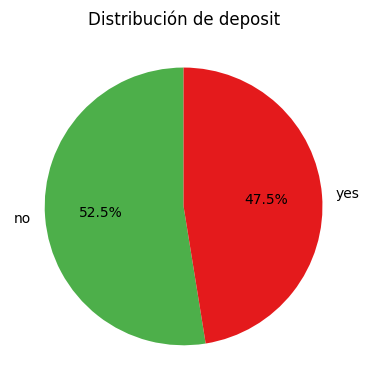

In [54]:
# value_counts() cuenta cuántas veces aparece cada clase de la variable deposit
proporciones = df["deposit"].value_counts(normalize=True) * 100

# Comprobamos que no haya mas de un 70% de datos que pertenecen a una sola clase, ya que significaria que esta desbalanceado
target = "deposit"
if proporciones.iloc[0] > 70:
    print(f"El target '{target}' está desbalanceado: {proporciones.iloc[0]:.2f} de la clase mayoritaria.")

# Gráfico pie para visualizar la distribución del target
plt.figure(figsize=(4, 4))
proporciones.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4daf4a", "#e41a1c"],
    legend=False,
    ylabel=""
)
plt.title("Distribución de deposit")
plt.tight_layout()
plt.show()

Como observamos en el gráfico, los datos estan balanceados, ya que hay un 52,2% de "no" y 47,5% de "yes".

### Analisis pdays

Estadísticas generales de pdays:
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Los 10 valores más frecuentes de pdays:
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
 183      73
 184      51
 94       42
 93       40
 95       37
Name: count, dtype: int64
Número de clientes no contactados (pdays = -1): 8203
Número de clientes contactados (pdays != -1): 2797

Proporción de no contactados: 0.7457272727272727
Proporción de contactados: 0.25427272727272726


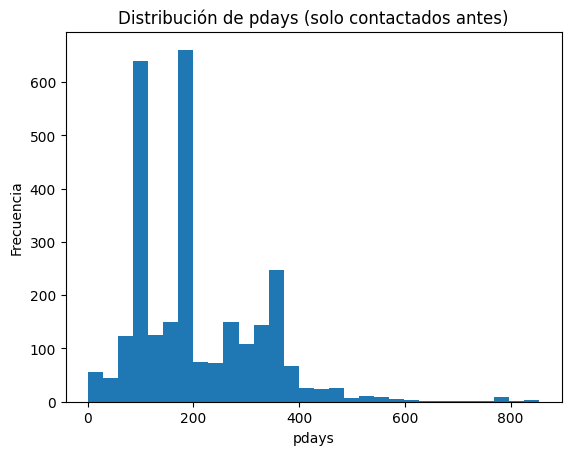

In [62]:
target = "pdays"

# Estadísticas generales
print(f"Estadísticas generales de {target}:")
print(df[target].describe())
print()
print(f"Los 10 valores más frecuentes de {target}:")
print(df[target].value_counts().head(10))

# Número de clientes no contactados (pdays = -1) vs contactados (pdays != -1)
n_not_contacted = (df[target] == -1).sum()
n_contacted = (df[target] != -1).sum()

print("Número de clientes no contactados (pdays = -1):", n_not_contacted)
print("Número de clientes contactados (pdays != -1):", n_contacted)

# Comparación de proporciones
print()
print("Proporción de no contactados:", n_not_contacted / len(df))
print("Proporción de contactados:", n_contacted / len(df))

# Histograma de pdays para los contactados (pdays != -1)
pdays_contacted = df.loc[df[target] != -1, target]
plt.hist(pdays_contacted, bins=30)
plt.title("Distribución de pdays (solo contactados antes)")
plt.xlabel("pdays")
plt.ylabel("Frecuencia")
plt.show()


La variable pdays respresenta el número de días desde el último contacto con el cliente. El valor de -1 indica que el cliente no habia sido contactado previamete.
Gracias a los resultados, vemos que el 74,6% de los clientes nunca habían sido contactados antes, mientras que el 25,4% sí habian sido contactados. Por esto, la mediana es -1.
Para analizar la distribución real de los días desde el último contacto, se excluyeron los valores -1, ya que son un caso especial y si no lo hicieramos, el histograma quedaría dominado por este valor.

## 2. Decidir como se va a realizar la evaluación

Como hemos analizado anteriormente, la variable objetivo está bastante balanceada (52% vs 48%). Es por esto que hemos elegido como métrica principal el Accuracy. Además, es una métrica con una interpretación sencilla que nos dirá el porcentaje de predicciones totales correctas y en escenarios equilibrados como este, Accuracy es una medida fiable de rendimiento general.


Por otro lado, aunque los datos estén balanceados, desde una perspectiva de negocio como es el banco, no todos los errores tienen el mismo coste. Al banco le interesa no perder clientes potenciales (falsos negativos). Por lo que utilizaremos además Recall para la clase "yes", permitiéndonos asegurar que el modelo sea capaz de identificar a la mayor cantidad posible de clientes dispuestos a suscribir el depósito.

### División holdout (train/test)

In [64]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y variable objetivo
x = df.drop(columns=["deposit"]) # Variables predictoras (features)
y = df["deposit"] # Variable objetivo (target)

# Dividir el conjunto de datos en entrenamiento y prueba (2/3 entrenamiento, 1/3 prueba)
# Usamos stratify=y para mantener la proporción de "yes" y "no" en ambos conjuntos
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3,
                                                    stratify=y,
                                                      random_state=100522236)

print("Tamaño del conjunto de entrenamiento:", x_train.shape[0])
print("Tamaño del conjunto de prueba:", x_test.shape[0])


Tamaño del conjunto de entrenamiento: 7333
Tamaño del conjunto de prueba: 3667


### Inner evaluation (crossvalidation)

Para la evaluación interna se empleará validación cruzada estratificada en 5 folds (Stratified 5-Fold CV), ya que garantiza que en cada una de las 5 particiones, la proporción de clientes que dicen 'yes' y 'no' no sea la misma que en el conjunto de entrenamiento, obtenemos una estimación mucho más fiable del rendimiento que si usáramos una única partición y porque nos ayudará a buscar los mejores hiperparámetros sin tocar el conjunto de test hasta el final.

In [65]:
from sklearn.model_selection import StratifiedKFold

# Definimos el esquema de validación cruzada para la evaluación interna (Inner)
cv = StratifiedKFold(
    n_splits=5, # 5 folds
    shuffle=True,
    random_state=100522236 # Utilizamos el NIA de Lidia para asegurar reproducibilidad
)